Rozpoczynam eksperyment na urządzeniu: cuda

>>> Testowanie Learning Rate: 0.1
   Próba 1/3 zakończona. Accuracy: 35.73%
   Próba 2/3 zakończona. Accuracy: 34.70%
   Próba 3/3 zakończona. Accuracy: 34.96%

>>> Testowanie Learning Rate: 0.01
   Próba 1/3 zakończona. Accuracy: 73.01%
   Próba 2/3 zakończona. Accuracy: 67.35%
   Próba 3/3 zakończona. Accuracy: 74.81%

>>> Testowanie Learning Rate: 0.001
   Próba 1/3 zakończona. Accuracy: 73.52%
   Próba 2/3 zakończona. Accuracy: 75.84%
   Próba 3/3 zakończona. Accuracy: 74.29%

>>> Testowanie Learning Rate: 0.0001
   Próba 1/3 zakończona. Accuracy: 69.15%
   Próba 2/3 zakończona. Accuracy: 69.41%
   Próba 3/3 zakończona. Accuracy: 68.12%


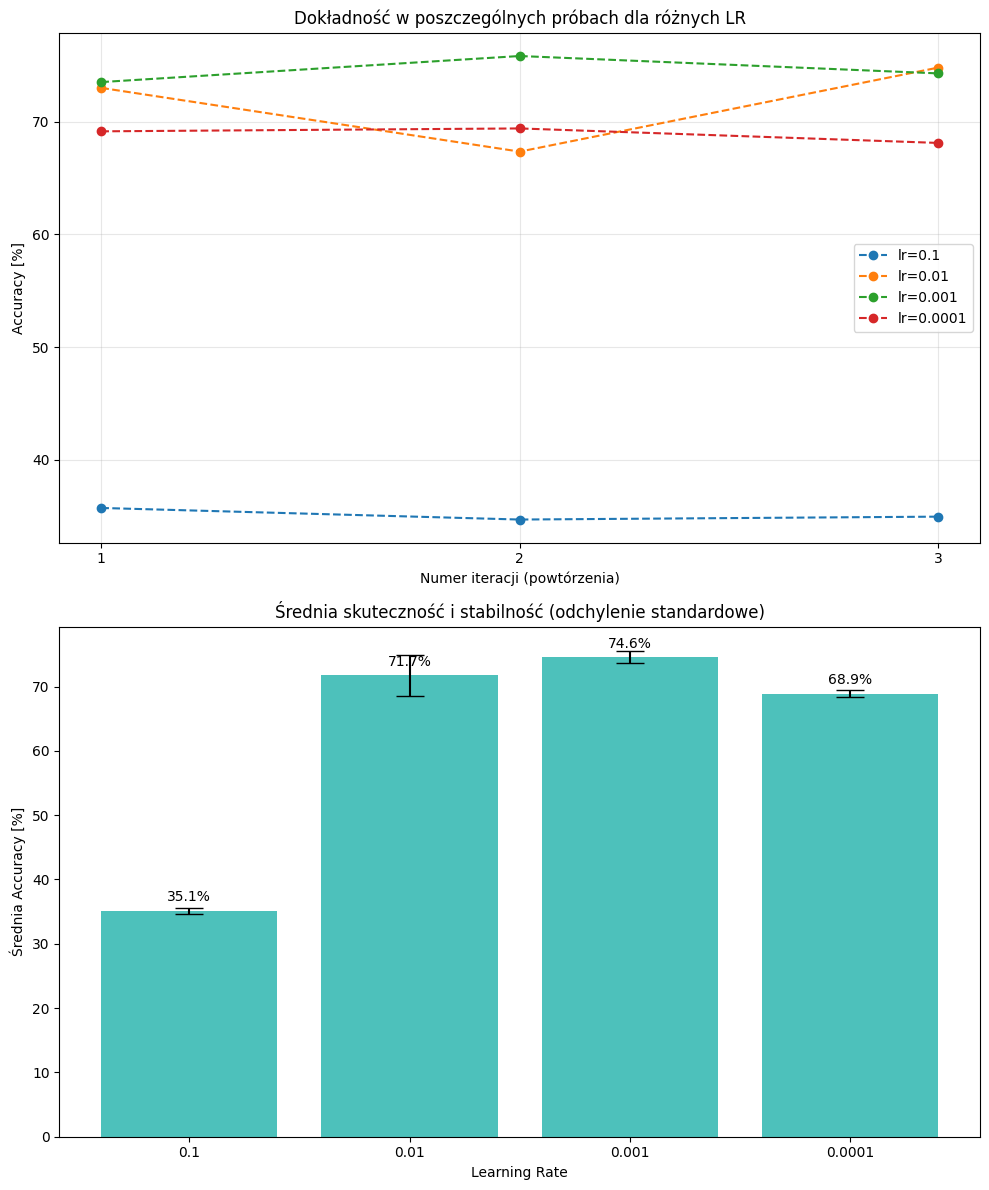

In [1]:
from ucimlrepo import fetch_ucirepo

steel_plates_faults = fetch_ucirepo(id=198)

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

X = steel_plates_faults.data.features
y = steel_plates_faults.data.targets

y = np.argmax(y.values, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.from_numpy(X_train_scaled).float().to(device)
X_test_tensor = torch.from_numpy(X_test_scaled).float().to(device)
y_train_tensor = torch.from_numpy(y_train).long().to(device)
y_test_tensor = torch.from_numpy(y_test).long().to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


class SteelFaultNet(nn.Module):
    def __init__(self):
        super(SteelFaultNet, self).__init__()
        self.fc1 = nn.Linear(27, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 7)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ==================== KONFIGURACJA EKSPERYMENTU ====================
lrs = [0.1, 0.01, 0.001, 0.0001]
num_repeats = 3  # Każdy LR testujemy 3 razy, by wykluczyć losowość
epochs = 20
final_results = {} 

print(f"Rozpoczynam eksperyment na urządzeniu: {device}")

for lr in lrs:
    print(f"\n>>> Testowanie Learning Rate: {lr}")
    run_accuracies = []
    
    for i in range(num_repeats):
        # 1. Inicjalizacja nowej instancji modelu (losowe wagi)
        model = SteelFaultNet().to(device) 
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()
        
        # 2. Pętla treningowa
        for epoch in range(epochs):
            model.train()
            for x_batch, y_batch in train_loader:
                optimizer.zero_grad()
                outputs = model(x_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
        
        # 3. Testowanie po 20 epokach
        model.eval()
        with torch.no_grad():
            outputs = model(X_test_tensor)
            _, predicted = torch.max(outputs, 1)
            acc = (predicted == y_test_tensor).float().mean().item() * 100
            run_accuracies.append(acc)
            print(f"   Próba {i+1}/{num_repeats} zakończona. Accuracy: {acc:.2f}%")
            
    final_results[lr] = run_accuracies

# ==================== GENEROWANIE WYKRESÓW ====================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# WYKRES 1: Szczegółowe wyniki każdej próby
for lr, accs in final_results.items():
    ax1.plot(range(1, num_repeats + 1), accs, marker='o', linestyle='--', label=f'lr={lr}')

ax1.set_title('Dokładność w poszczególnych próbach dla różnych LR')
ax1.set_xticks(range(1, num_repeats + 1))
ax1.set_xlabel('Numer iteracji (powtórzenia)')
ax1.set_ylabel('Accuracy [%]')
ax1.legend()
ax1.grid(True, alpha=0.3)

# WYKRES 2: Podsumowanie średnie z odchyleniem standardowym
means = [np.mean(final_results[lr]) for lr in lrs]
stds = [np.std(final_results[lr]) for lr in lrs]
labels = [str(lr) for lr in lrs]

bars = ax2.bar(labels, means, yerr=stds, capsize=10, color='lightseagreen', alpha=0.8)
ax2.set_title('Średnia skuteczność i stabilność (odchylenie standardowe)')
ax2.set_ylabel('Średnia Accuracy [%]')
ax2.set_xlabel('Learning Rate')

# Dodanie wartości nad słupkami
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

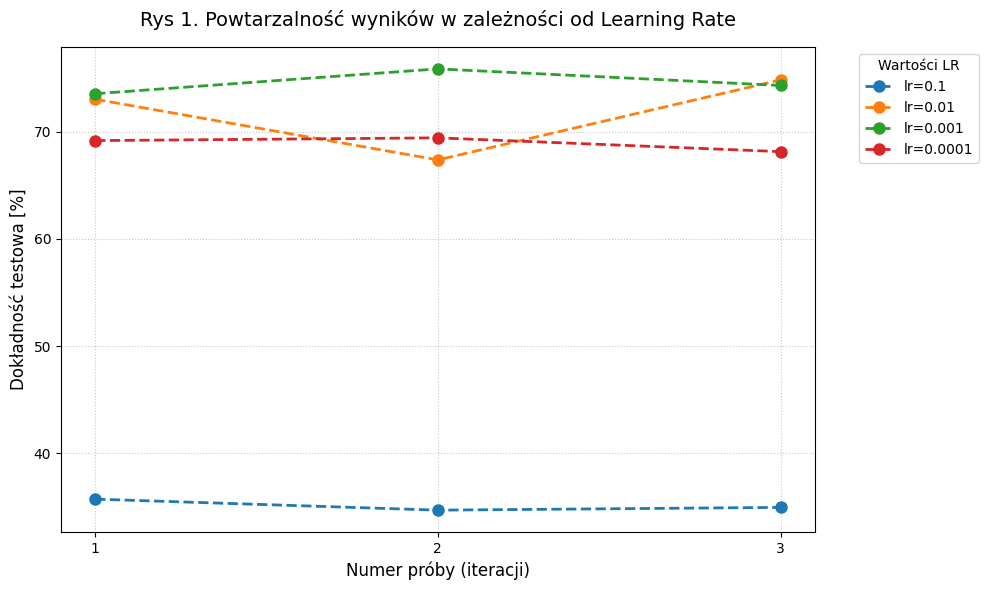

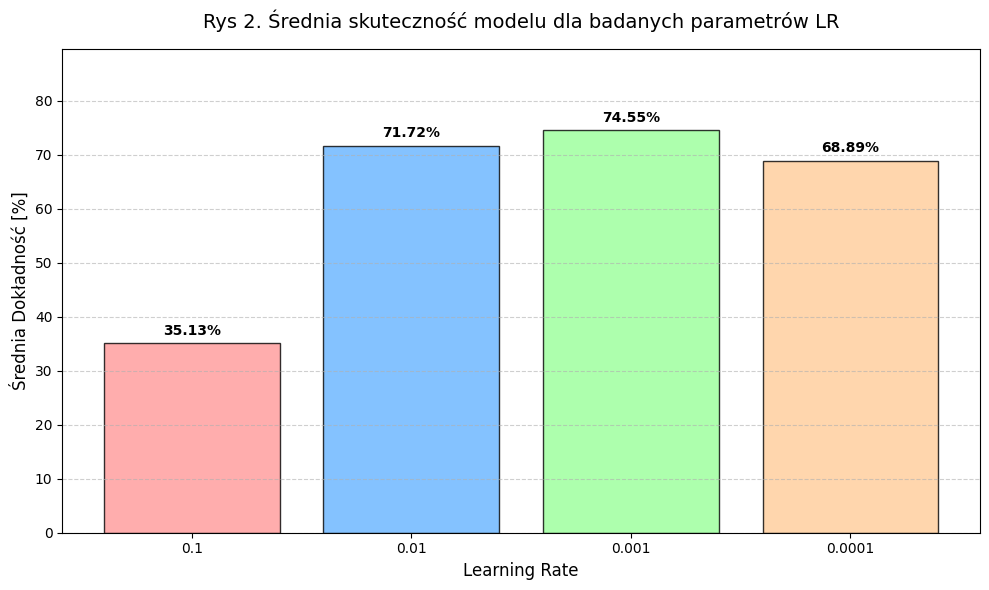

In [2]:
# WYKRES 1: Szczegółowe wyniki każdej próby (Rozrzut)
plt.figure(figsize=(10, 6))
for lr, accs in final_results.items():
    plt.plot(range(1, num_repeats + 1), accs, marker='o', linestyle='--', linewidth=2, markersize=8, label=f'lr={lr}')

plt.title('Rys 1. Powtarzalność wyników w zależności od Learning Rate', fontsize=14, pad=15)
plt.xticks(range(1, num_repeats + 1))
plt.xlabel('Numer próby (iteracji)', fontsize=12)
plt.ylabel('Dokładność testowa [%]', fontsize=12)
plt.legend(title="Wartości LR", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show() # To otworzy pierwsze okno

# WYKRES 2: Podsumowanie średnie
plt.figure(figsize=(10, 6))
means = [np.mean(final_results[lr]) for lr in lrs]
labels = [str(lr) for lr in lrs]

colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99'] # Estetyczne kolory słupków
bars = plt.bar(labels, means, color=colors, alpha=0.8, edgecolor='black', linewidth=1)

plt.title('Rys 2. Średnia skuteczność modelu dla badanych parametrów LR', fontsize=14, pad=15)
plt.ylabel('Średnia Dokładność [%]', fontsize=12)
plt.xlabel('Learning Rate', fontsize=12)
plt.ylim(0, max(means) + 15) # Dodatkowy margines na górze dla etykiet
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Dodanie wartości procentowych nad słupkami
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

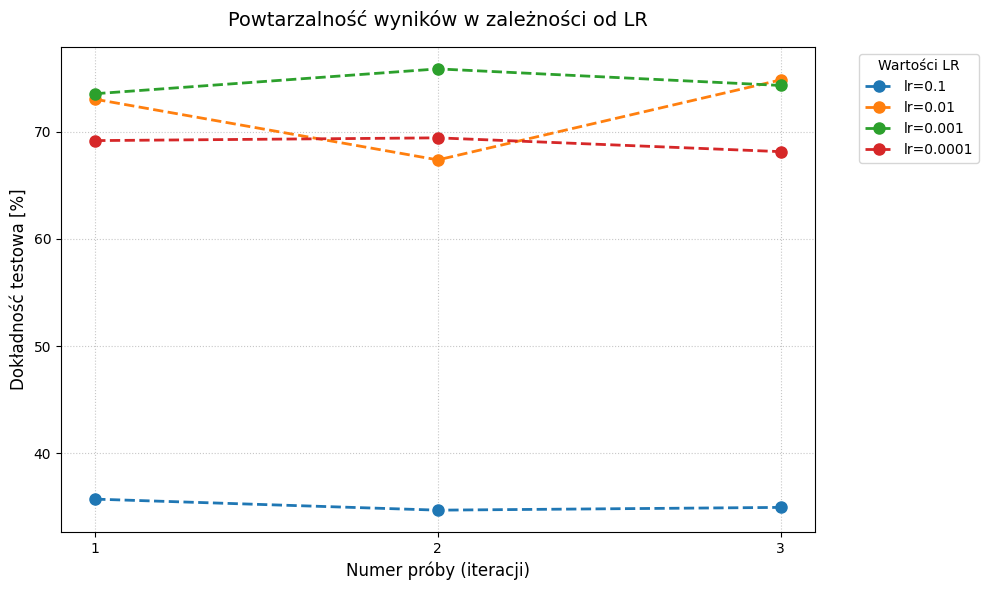

In [3]:
plt.figure(figsize=(10, 6))
for lr, accs in final_results.items():
    plt.plot(range(1, num_repeats + 1), accs, marker='o', linestyle='--', linewidth=2, markersize=8, label=f'lr={lr}')

plt.title('Powtarzalność wyników w zależności od LR', fontsize=14, pad=15)
plt.xticks(range(1, num_repeats + 1))
plt.xlabel('Numer próby (iteracji)', fontsize=12)
plt.ylabel('Dokładność testowa [%]', fontsize=12)
plt.legend(title="Wartości LR", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show() # To otworzy pierwsze okno

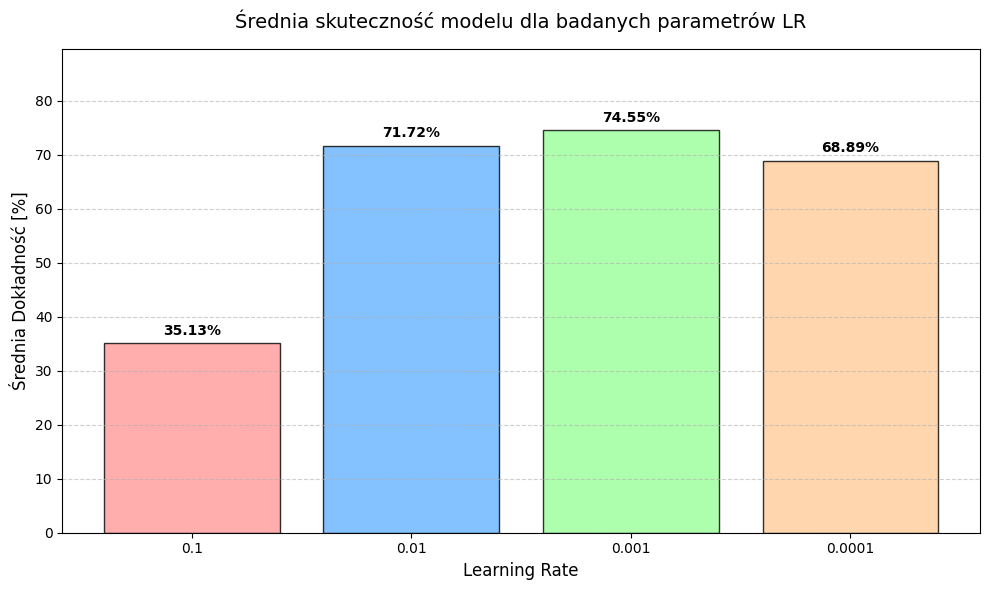

In [4]:
# WYKRES 2: Podsumowanie średnie
plt.figure(figsize=(10, 6))
means = [np.mean(final_results[lr]) for lr in lrs]
labels = [str(lr) for lr in lrs]

colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99'] # Estetyczne kolory słupków
bars = plt.bar(labels, means, color=colors, alpha=0.8, edgecolor='black', linewidth=1)

plt.title('Średnia skuteczność modelu dla badanych parametrów LR', fontsize=14, pad=15)
plt.ylabel('Średnia Dokładność [%]', fontsize=12)
plt.xlabel('Learning Rate', fontsize=12)
plt.ylim(0, max(means) + 15) # Dodatkowy margines na górze dla etykiet
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Dodanie wartości procentowych nad słupkami
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

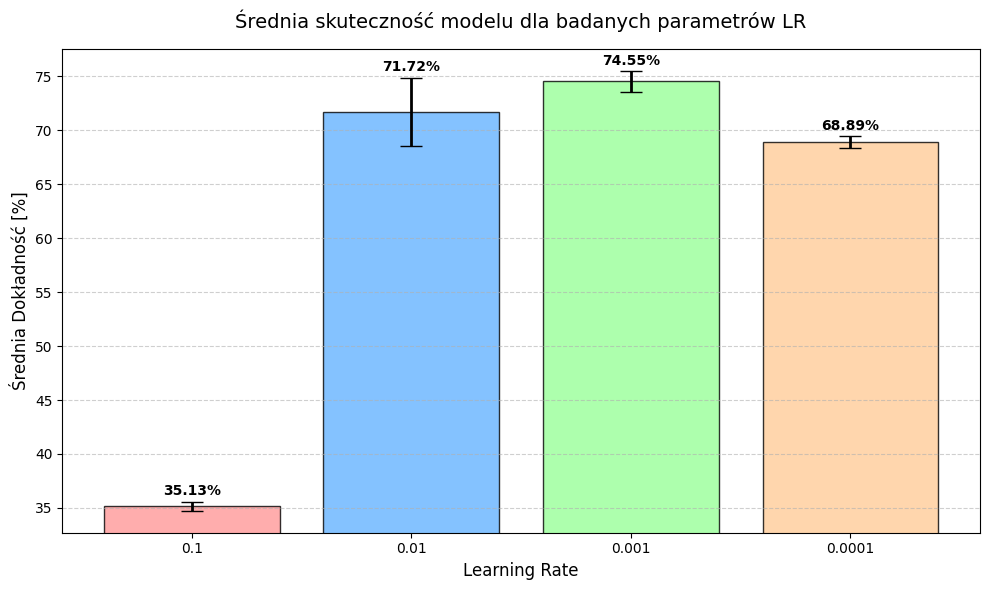

In [6]:
plt.figure(figsize=(10, 6))
means = [np.mean(final_results[lr]) for lr in lrs]
std = [np.std(final_results[lr]) for lr in lrs]
labels = [str(lr) for lr in lrs]

colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99'] # Estetyczne kolory słupków
# bars = plt.bar(labels, means, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
bars = plt.bar(
    labels, 
    means, 
    yerr=std, 
    color=colors, 
    alpha=0.8, 
    edgecolor='black', 
    capsize=8, # Zwiększyłem daszki, żeby były bardziej widoczne
    error_kw={'ecolor': 'black', 'elinewidth': 2} # Grubsza linia wąsów
)

plt.title('Średnia skuteczność modelu dla badanych parametrów LR', fontsize=14, pad=15)
plt.ylabel('Średnia Dokładność [%]', fontsize=12)
plt.xlabel('Learning Rate', fontsize=12)
# plt.ylim(0, max(means) + 15) # Dodatkowy margines na górze dla etykiet
ymin = min([m - s for m, s in zip(means, std)]) - 2  # -2 dla zapasu z dołu
ymax = min(max([m + s for m, s in zip(means, std)]) + 2, 102) # max do 102%, żeby nie przesadzić

plt.ylim(ymin, ymax) 
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Dodanie wartości procentowych nad słupkami
for i, bar in enumerate(bars):
    yval = bar.get_height()
    sd = std[i]
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + sd + 0.3, # 0.3% powyżej górnego wąsa błędu
        f'{yval:.2f}%', 
        ha='center', 
        va='bottom', 
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()